## Google Drive Setup and Workspace Configuration
This section mounts Google Drive to access project files and sets up the base working directory for the project.

In [ ]:
!pip install -U "tensorflow" "keras>=3.2.0,<4"
# Import all necessary libraries
!pip install segmentation-models-3D
!pip install plotly
!pip install split-folders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 33.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.34.0 which is incompatibl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires keras>=3.12.0, but you have keras 3.3.3 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.
keras-hub 0.26.0 requires keras>=3.13, but you have keras 3.3.3 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.21.0 which is incompatible.


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_COLAB_PATH = "/content/drive/MyDrive/Master By Research/UVNET"
os.chdir(BASE_COLAB_PATH)
MODEL_SAVE_PATH = os.path.join(BASE_COLAB_PATH, "Model")
BRAIN_TUMOR_DATA_PATH = os.path.join(BASE_COLAB_PATH, "BraTS2020_TrainingData")

# Create the model save directory if it doesn't exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

## Library Imports
This section imports all necessary libraries for the project, including standard libraries for data handling, numerical operations, and visualization, as well as specialized libraries for deep learning with TensorFlow and Keras, and 3D segmentation models.

In [ ]:
# Standard library imports
import random
import glob
import gc # For garbage collection and clearing Keras session

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import nibabel as nib

# TensorFlow and Keras imports
import tensorflow as tf
import keras # Main Keras import
import tensorflow.keras.backend as K # For K.clear_session(), etc.
import segmentation_models_3D as sm

# Keras components for model building and training (using tensorflow.keras for explicit Keras 3 compatibility)
from keras.models import Model, load_model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Dropout, Lambda, Activation, Dense, Maximum
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.losses import Loss
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import MeanIoU

# Local module imports
import AE_UVNet as model
import custom_datagen

Segmentation Models: using `keras` framework.


Checking case: 83


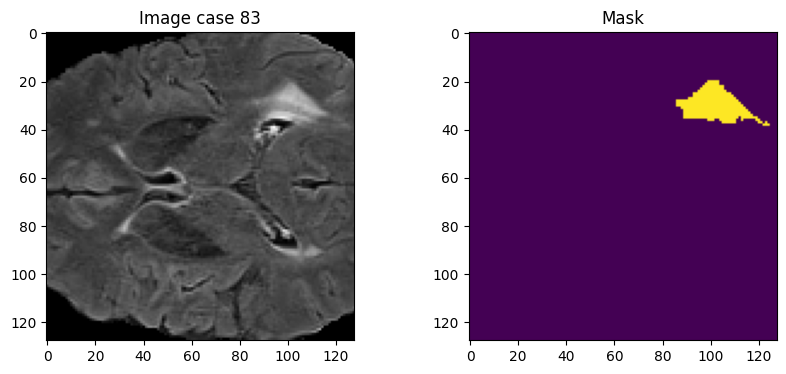

Checking case: 125


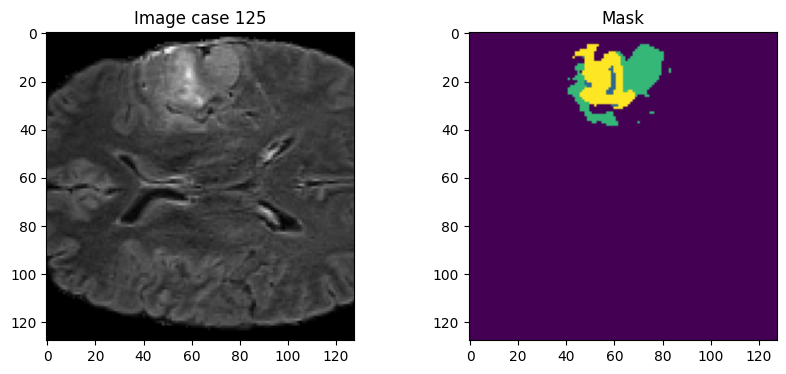

In [ ]:
# Directory paths
image_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/train/images/")
mask_dir  = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/train/masks/")

# All mask files
mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".npy")]

# Randomly select a few cases
num_samples = 2
selected_masks = random.sample(mask_files, num_samples)

for mask_name in selected_masks:

    # Extract ID
    case_id = mask_name.split("_")[1].split(".")[0]

    image_name = f"image_{case_id}.npy"

    image_path = os.path.join(image_dir, image_name)
    mask_path  = os.path.join(mask_dir, mask_name)

    # Read data
    image = np.load(image_path)
    mask  = np.load(mask_path)

    # If mask is one-hot encoded
    if mask.ndim == 4:
        mask = np.argmax(mask, axis=-1)

    # Get center slice
    center_slice = mask.shape[2] // 2

    print("Checking case:", case_id)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image[:,:,center_slice,0], cmap="gray")
    plt.title(f"Image case {case_id}")

    plt.subplot(1,2,2)
    plt.imshow(mask[:,:,center_slice])
    plt.title("Mask")

    plt.show()

## Imports and Directory Configuration
All necessary libraries have been imported, and the working directory is set to access the dataset and project files.

## Data Preparation and Visualization
Directories for training and validation images and masks are defined. A random MRI slice along with its corresponding segmentation mask is visualized to confirm the data loading process.

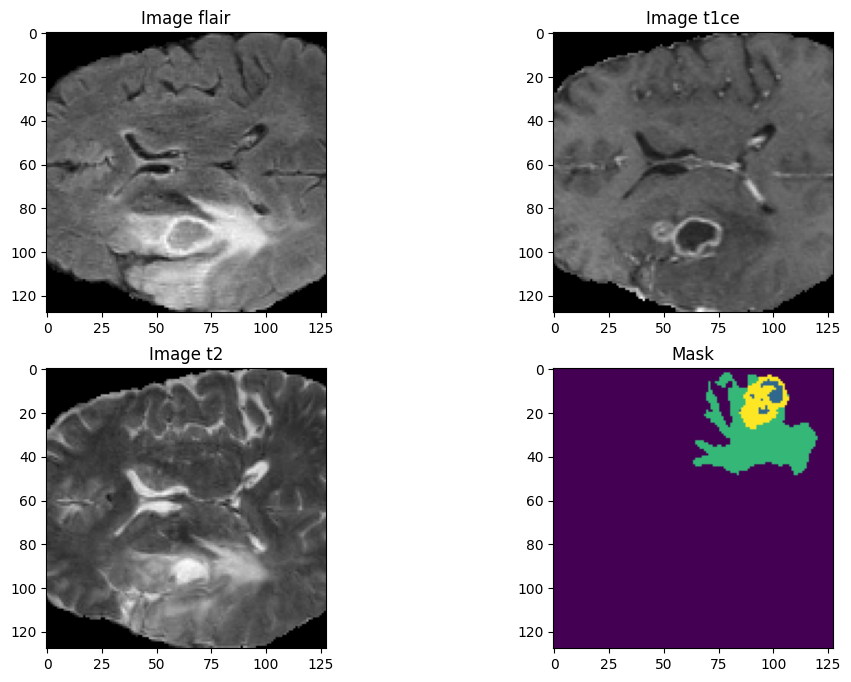

In [ ]:
# ####################################################
# Set the directories containing training images and masks

# Old path for 128x128 data
# train_img_dir = "/workspace/BraTS2020_TrainingData/input_data_128/train/images/"
# train_mask_dir = "/workspace/BraTS2020_TrainingData/input_data_128/train/masks/"

# Current path for 3-channel input data
train_img_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_3channels/images/")
train_mask_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_3channels/masks/")

# Get list of image and mask filenames from the directories
img_list = os.listdir(train_img_dir)
msk_list = os.listdir(train_mask_dir)

# Get the total number of images available for visualization
num_images = len(os.listdir(train_img_dir))

# Randomly select one image/mask pair
img_num = random.randint(0,num_images-1)
test_img = np.load(train_img_dir+img_list[img_num])

# Convert one-hot encoded mask to class index mask
test_mask = np.load(train_mask_dir+msk_list[img_num])
test_mask = np.argmax(test_mask, axis=3)

# Randomly select one slice index along the depth axis
n_slice=random.randint(0, test_mask.shape[2])

# Visualize the selected slice for each modality and the corresponding mask
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

## Class Balance
This section computes the pixel frequency for each segmentation class and calculates weights to address class imbalance during training.

In [ ]:
# To find the weights for the model based on the dataset
columns = ['0', '1', '2', '3']
df = pd.DataFrame(columns=columns)

train_mask_list = sorted(glob.glob(os.path.join(BRAIN_TUMOR_DATA_PATH, 'input_data_128/train/masks/*.npy')))

for img_path in train_mask_list:
    mask = np.load(img_path)
    mask_argmax = np.argmax(mask, axis=-1)

    val, counts = np.unique(mask_argmax, return_counts=True)
    class_count = {str(k): 0 for k in range(4)}  # ensure all classes included
    class_count.update(dict(zip(map(str, val), counts)))

    df = pd.concat([df, pd.DataFrame([class_count])], ignore_index=True)

df = df.fillna(0)

# Sum counts for each class
label_0 = df['0'].sum()
label_1 = df['1'].sum()
label_2 = df['2'].sum()
label_3 = df['3'].sum()

print("Label 0:", label_0)
print("Label 1:", label_1)
print("Label 2:", label_2)
print("Label 3:", label_3)

# Compute weights only if all labels are present
if all(x > 0 for x in [label_0, label_1, label_2, label_3]):
    total = label_0 + label_1 + label_2 + label_3
    wt0 = 1.0 - (label_0 / total)
    wt1 = 1.0 - (label_1 / total)
    wt2 = 1.0 - (label_2 / total)
    wt3 = 1.0 - (label_3 / total)
    class_weights = np.array([wt0, wt1, wt2, wt3], dtype=np.float32)
    print("Class weights:", class_weights)
else:
    print("One or more labels are missing from your data!")

Label 0: 547201124
Label 1: 6076965
Label 2: 16138730
Label 3: 5202829
Class weights: [0.04771595 0.98942435 0.97191405 0.99094564]


/tmp/ipykernel_728/3852678960.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


## Custom Data Generator (Train/Validation)
This section establishes custom data generators for the training and validation datasets.

In [ ]:
# --------------------------------------------------------------------
# Optional class weights for Dice loss function in segmentation
# These weights are used to balance the loss based on class imbalance.
# For example:
#   - Class 0 = background
#   - Class 1 = edema
#   - Class 2 = non-enhancing tumor
#   - Class 3 = enhancing tumor
##############################################################

#These are custom weights that can be used to train the model

# wt0, wt1, wt2, wt3 = 0.25, 0.25, 0.25, 0.25
# wt0, wt1, wt2, wt3 = 0.05, 0.3, 0.3, 0.35
# wt0, wt1, wt2, wt3 = 0.05, 0.25, 0.3, 0.4


##############################################################
#Define the image generators for training and validation

# train_img_dir = "/workspace/BraTS2020_TrainingData/input_data_3channels/input_data_test/train/images/"
# train_mask_dir = "/workspace/BraTS2020_TrainingData/input_data_128/train/masks/"

# val_img_dir = "/workspace/BraTS2020_TrainingData/input_data_128/val/images/"
# val_mask_dir = "/workspace/BraTS2020_TrainingData/input_data_128/val/masks/"

train_img_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/train/images/")
train_mask_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/train/masks/")

val_img_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/val/images/")
val_mask_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/val/masks/")

train_img_list=os.listdir(train_img_dir)
train_mask_list = os.listdir(train_mask_dir)

val_img_list=os.listdir(val_img_dir)
val_mask_list = os.listdir(val_mask_dir)

In [ ]:
batch_size = 1

train_img_datagen = custom_datagen.imageLoader(train_img_dir, train_img_list,
                                train_mask_dir, train_mask_list, batch_size)

val_img_datagen = custom_datagen.imageLoader(val_img_dir, val_img_list,
                                val_mask_dir, val_mask_list, batch_size)


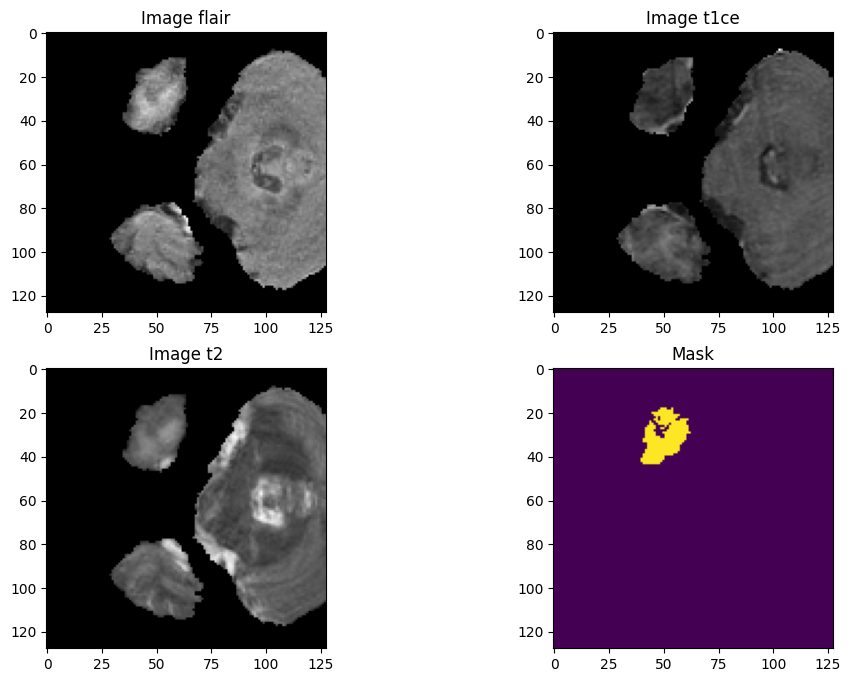

In [ ]:
# Verify if the Custom generator works
img, msk = train_img_datagen.__next__()

img_num = random.randint(0,img.shape[0]-1)
test_img=img[img_num]
test_mask=msk[img_num]
test_mask=np.argmax(test_mask, axis=3)

n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

## Define Loss Functions and Optimiser
This section outlines a composite loss function that combines Dice, Focal, and Tversky losses, tailored for imbalanced multi-class segmentation.

In [ ]:
# --------------------------------------------------------------------
# Optional class weights for Dice loss function in segmentation
# These weights are used to balance the loss based on class imbalance.
# For example:
#   - Class 0 = background
#   - Class 1 = edema
#   - Class 2 = non-enhancing tumor
#   - Class 3 = enhancing tumor

#Define loss, metrics and optimizer to be used for training
#wt0, wt1, wt2, wt3 = 0.25,0.25,0.25,0.25
#wt0, wt1, wt2, wt3 = 0.05, 0.3, 0.3, 0.35
#wt0, wt1, wt2, wt3 = 0.05, 0.25, 0.3, 0.4
#wt0, wt1, wt2, wt3 = 0.01, 0.4, 0.3, 0.29
#wt0, wt1, wt2, wt3 = 0.02, 0.35, 0.3, 0.33
#wt0, wt1, wt2, wt3 = 0.04748414, 0.98942566, 0.9724011, 0.99068916

class_weights = np.array([wt0, wt1, wt2, wt3], dtype=np.float32)
dice_loss = sm.losses.DiceLoss(class_weights=class_weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

#metrics = ['accuracy', sm.metrics.IOUScore(threshold=0.5)]
metrics = ['accuracy', sm.metrics.FScore(beta=1, threshold=0.5)]

LR = 0.0001
optim = keras.optimizers.Adam(LR)

In [ ]:
# class_weights = np.array([wt0, wt1, wt2, wt3], dtype=np.float32)
# dice_loss = sm.losses.DiceLoss(class_weights=class_weights)
# focal_loss = sm.losses.CategoricalFocalLoss()
# total_loss = dice_loss + (1 * focal_loss)


# def dice_loss(y_true, y_pred, smooth=1e-6):
#     y_true_f = K.flatten(y_true)
#     y_pred_f = K.flatten(y_pred)
#     intersection = K.sum(y_true_f * y_pred_f)
#     return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# def bce_dice_loss(y_true, y_pred):
#     bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
#     d_loss = dice_loss(y_true, y_pred)
#     return bce + d_loss
# #metrics = ['accuracy', sm.metrics.IOUScore(threshold=0.5)]


def tversky_loss_fn(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    TP = K.sum(y_true_f * y_pred_f)
    FP = K.sum((1 - y_true_f) * y_pred_f)
    FN = K.sum(y_true_f * (1 - y_pred_f))

    tversky_index = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
    return 1 - tversky_index

class CompositeLoss(Loss):
    def __init__(self, dice_loss, focal_loss, alpha=0.7, beta=0.3, tversky_weight=0.2):
        super().__init__()
        self.dice = dice_loss
        self.focal = focal_loss
        self.alpha = alpha
        self.beta = beta
        self.tversky_weight = tversky_weight

    def call(self, y_true, y_pred):
        tversky = tversky_loss_fn(y_true, y_pred, self.alpha, self.beta)
        return self.dice(y_true, y_pred) + 0.5 * self.focal(y_true, y_pred) + self.tversky_weight * tversky

dice_loss = sm.losses.DiceLoss(class_weights=class_weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = CompositeLoss(dice_loss, focal_loss)

In [ ]:
print("Class weights:", class_weights)

Class weights: [0.04771595 0.98942435 0.97191405 0.99094564]


## Model Compilation and Training
This section builds the model, compiles it with the custom loss and metrics, and trains it with early stopping.

In [ ]:
#Fit the model
K.clear_session()
gc.collect()
steps_per_epoch = len(train_img_list)//batch_size
val_steps_per_epoch = len(val_img_list)//batch_size

In [ ]:
# Print the model architecture summary
# This shows the number of parameters, layers, and output shapes at each stage
import gc
K.clear_session()
gc.collect()
model = model.build_model(
        model_name='uvnet',
        input_shape=(128, 128, 128, 3),
        n_classes=4,
        base_filters=8
    )
model.compile(optimizer = optim, loss=total_loss, metrics=metrics)
print(model.summary())

Model: "Hybrid_DeepResUVNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │        656 │ input_layer[0][0] │
│                     │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         32 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d   │ (None, 128, 128,  │          0 │ activation[0][0]  │
│ (SpatialDropout3D)  │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 128, 128,  │      1,736 │ spatial_dropout3… │
│                     │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 128, 128,  │         32 │ input_layer[0][0] │
│                     │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         32 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         32 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128, 8)           │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 128, 8)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 64, 64,    │      1,040 │ activation_1[0][… │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 64, 64,    │      6,928 │ activation_2[0][… │
│                     │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv3d_4[0][0]  

 Total params: 1,221,411 (4.66 MB)

 Trainable params: 1,219,651 (4.65 MB)

 Non-trainable params: 1,760 (6.88 KB)

None


In [ ]:
# Print the input and the output shape of the model
print(model.input_shape)
print(model.output_shape)

(None, 128, 128, 128, 3)
(None, 128, 128, 128, 4)


In [ ]:
img, msk = next(train_img_datagen)
# Troubleshoot: Check if both outputs are of type float32; if not, there is an error with the structure of the model
print(img.dtype, msk.dtype)

float32 float32


## Callbacks for Robust Model Training
This section defines two essential callbacks for model training: `EarlyStopping` and `ModelCheckpoint`. `EarlyStopping` monitors a validation metric (e.g., `val_loss`) and stops training if the metric does not improve for a specified number of epochs (`patience`), preventing overfitting and saving computational resources. `ModelCheckpoint` saves the model's weights whenever a monitored metric achieves its best value, ensuring that the best performing model during training is preserved. The `checkpoint_filepath` specifies where the best model will be saved.

In [ ]:
# Define an EarlyStopping callback to prevent overfitting and reduce training time
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
print(os.getcwd())

/content/drive/MyDrive/Master By Research/UVNET


In [ ]:
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Fix for NumPy 2.0 incompatibility with older Keras versions using np.Inf
np.Inf = np.inf

checkpoint_filepath = os.path.join(MODEL_SAVE_PATH, 'best_model.keras')

checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

## Model Training Execution
This section initiates the model training process using the `fit` method. The model is trained on data provided by `train_img_datagen` for a specified number of epochs. Validation is performed using `val_img_datagen` to monitor performance on unseen data. The `callbacks` (EarlyStopping and ModelCheckpoint) are applied to manage training duration and save the best model. After training completes, the final model is saved to the specified `MODEL_SAVE_PATH`.

In [ ]:
history = model.fit(
    train_img_datagen,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    verbose=1,
    validation_data=val_img_datagen,
    validation_steps=val_steps_per_epoch,
    callbacks=[checkpoint, early_stop]
)

model.save(os.path.join(MODEL_SAVE_PATH, 'AE-UVNet.keras'))

Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.3166 - f1-score: 0.1321 - loss: 1.1366
Epoch 1: val_loss improved from inf to 1.11859, saving model to /content/drive/MyDrive/Master By Research/UVNET/Model/best_model.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.3172 - f1-score: 0.1322 - loss: 1.1365 - val_accuracy: 0.8710 - val_f1-score: 0.0774 - val_loss: 1.1186
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7748 - f1-score: 0.2497 - loss: 1.0968
Epoch 2: val_loss did not improve from 1.11859
274/274 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.7750 - f1-score: 0.2497 - loss: 1.0967 - val_accuracy: 0.7627 - val_f1-score: 0.1478 - val_loss: 1.1417
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9126 - f1-score: 0.3296 - loss: 1.0785
Epoch 3: val_loss did not improve from 1.11859
274/274 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.9126 - f1-score: 0.3296 - loss: 1.0785 - val_accuracy: 0.8080 - val_f1-score:

## Resumable Model Training Execution
This section provides a more robust training setup that supports resuming training from a saved checkpoint. It first checks for an existing checkpoint file; if found, it loads the model from that checkpoint and recompiles it. Otherwise, a new model is built and compiled. This ensures continuity in training, especially for long-running experiments. The training then proceeds with the defined data generators, callbacks (EarlyStopping and ModelCheckpoint), and epochs, and the final best model is saved.

In [ ]:
# Define the checkpoint file path
checkpoint_filepath = os.path.join(MODEL_SAVE_PATH, 'AE-UVNet_checkpoint.keras')

# Check if a checkpoint exists to resume training
if os.path.exists(checkpoint_filepath):
    print(f"Loading model from {checkpoint_filepath} to resume training.")
    # Load the model and recompile it with the defined optimizer, loss, and metrics
    model = load_model(checkpoint_filepath, compile=False)
    model.compile(optimizer=optim, loss=total_loss, metrics=metrics)
else:
    print("No checkpoint found. Building a new model.")
    # Clear Keras session and garbage collect to free up memory
    K.clear_session()
    gc.collect()
    # Build a new model using the defined architecture
    model = model.build_model(
        model_name='uvnet',
        input_shape=(128, 128, 128, 3),
        n_classes=4,
        base_filters=8
    )
    # Compile the new model
    model.compile(optimizer=optim, loss=total_loss, metrics=metrics)
    print(model.summary())

# Define ModelCheckpoint callback to save the best model during training
checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min' # 'min' because we want to minimize validation loss
)

# Combine EarlyStopping and ModelCheckpoint callbacks
callbacks_list = [early_stop, checkpoint]

# Calculate steps per epoch for training and validation
# These variables (train_img_list, val_img_list, batch_size) are assumed to be defined in previous cells.
steps_per_epoch = len(train_img_list) // batch_size
val_steps_per_epoch = len(val_img_list) // batch_size

print("Starting training...")
# Train the model with the defined data generators, callbacks, and epochs
history = model.fit(train_img_datagen,
          steps_per_epoch=steps_per_epoch,
          epochs=100,
          verbose=1,
          validation_data=val_img_datagen,
          validation_steps=val_steps_per_epoch,
          callbacks=callbacks_list
          )

# Save the final model (which will have the best weights due to EarlyStopping's restore_best_weights=True)
model.save(os.path.join(MODEL_SAVE_PATH, 'AE-UVNet.keras'))
print("Final model saved as AE-UVNet.keras")

## Training History Analysis and Visualization
After the model training is complete, this section focuses on analyzing and visualizing the training history. It extracts the accuracy and loss values from the `history` object recorded during training. A pandas DataFrame is created to display the training and validation accuracy per epoch, providing a tabular overview of the model's learning progression. Additionally, plots are generated to visualize the training and validation loss, as well as training and validation accuracy over epochs, which helps in identifying trends like overfitting or underfitting.

In [ ]:
# Create a pandas DataFrame to store accuracy metrics for each epoch
# And Display the DataFrame
acc_df = pd.DataFrame({
    'Epoch': list(range(1, len(history.history['accuracy']) + 1)),
    'Training Accuracy': history.history['accuracy'],
    'Validation Accuracy': history.history['val_accuracy']
})
display(acc_df)

,Epoch,Training Accuracy,Validation Accuracy
0,1,0.482918,0.871014
1,2,0.820557,0.762670
2,3,0.914572,0.807969
3,4,0.936294,0.791320
4,5,0.942563,0.839644
...,...,...,...
66,67,0.990388,0.967960
67,68,0.990515,0.953668
68,69,0.990460,0.961166
69,70,0.990496,0.970481


In [ ]:
# Print the Training and validation accuracies
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Final Training Accuracy: 0.9906
Final Validation Accuracy: 0.9571


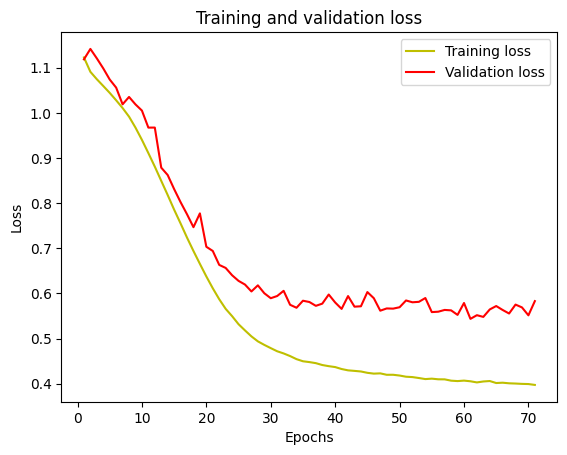

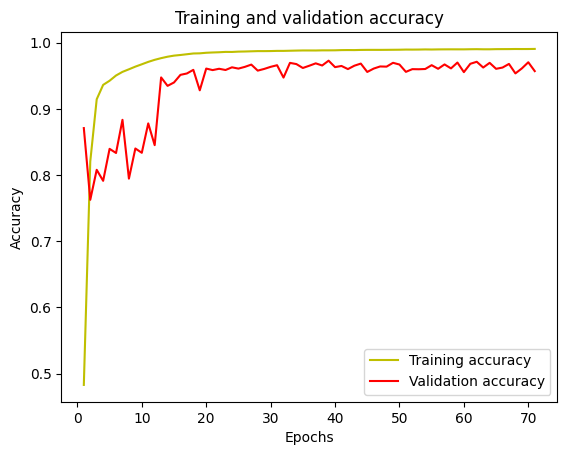

In [ ]:
# plot the training and validation IoU and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [35]:
#For predictions you do not need to compile the model
my_model = load_model(os.path.join(MODEL_SAVE_PATH, 'best_model.keras'),
                      compile=False)

In [36]:
test_img_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/val/images/")
test_mask_dir = os.path.join(BRAIN_TUMOR_DATA_PATH, "input_data_128/val/masks/")

test_img_list = os.listdir(test_img_dir)
test_mask_list = os.listdir(test_mask_dir)

In [37]:
#Verify IoU on a batch of images from the test dataset
#Using built in keras function for IoU
#Only works on TF > 2.0

# batch_size=1 #Check IoU for a batch of images
# test_img_datagen = custom_datagen.imageLoader(val_img_dir, val_img_list,
#                                 val_mask_dir, val_mask_list, batch_size)

batch_size = 1
test_img_datagen = custom_datagen.imageLoader(test_img_dir, test_img_list,
                                               test_mask_dir, test_mask_list, batch_size)

In [38]:
#Verify the generator
test_image_batch, test_mask_batch = test_img_datagen.__next__()

test_mask_batch_argmax = np.argmax(test_mask_batch, axis=4)
test_pred_batch = my_model.predict(test_image_batch)
test_pred_batch_argmax = np.argmax(test_pred_batch, axis=4)

n_classes = 4
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(test_pred_batch_argmax, test_mask_batch_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Mean IoU = 0.66072613


In [39]:
# Convert predictions and masks to one-hot
y_true = to_categorical(test_mask_batch_argmax, num_classes=4)
y_pred = to_categorical(test_pred_batch_argmax, num_classes=4)

def dice_score(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

# Per-class Dice
for i in range(4):
    d = dice_score(y_true[:, :, :, :, i], y_pred[:, :, :, :, i])
    print(f"Dice score for class {i}: {d:.4f}")

print(f"Mean Dice score: {np.mean([dice_score(y_true[:, :, :, :, i], y_pred[:, :, :, :, i]) for i in range(4)]):.4f}")


Dice score for class 0: 0.9959
Dice score for class 1: 0.2114
Dice score for class 2: 0.9174
Dice score for class 3: 0.8135
Mean Dice score: 0.7345


In [40]:
# Dice Scores for WT,ET and TC
def dice_score_binary(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)


In [41]:
true_mask_argmax = test_mask_batch_argmax
pred_mask_argmax = test_pred_batch_argmax
# Whole Tumor (WT): 1, 2, 3
true_wt = np.isin(true_mask_argmax, [1, 2, 3]).astype(np.uint8)
pred_wt = np.isin(pred_mask_argmax, [1, 2, 3]).astype(np.uint8)

# Tumor Core (TC): 1, 3
true_tc = np.isin(true_mask_argmax, [1, 3]).astype(np.uint8)
pred_tc = np.isin(pred_mask_argmax, [1, 3]).astype(np.uint8)

# Enhancing Tumor (ET): 3
true_et = (true_mask_argmax == 3).astype(np.uint8)
pred_et = (pred_mask_argmax == 3).astype(np.uint8)


In [34]:
wt_dice = dice_score_binary(true_wt, pred_wt)
tc_dice = dice_score_binary(true_tc, pred_tc)
et_dice = dice_score_binary(true_et, pred_et)
mean = (wt_dice+tc_dice+et_dice)/3
print(f"Whole Tumor Dice (WT): {wt_dice:.4f}")
print(f"Tumor Core Dice (TC): {tc_dice:.4f}")
print(f"Enhancing Tumor Dice (ET): {et_dice:.4f}")
print(f"mean :{mean:.4f}")

Whole Tumor Dice (WT): 0.9142
Tumor Core Dice (TC): 0.8626
Enhancing Tumor Dice (ET): 0.7754
mean :0.8507
